In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/UROP"

def print_tree(path, indent=""):
    try:
        for item in sorted(os.listdir(path)):
            full_path = os.path.join(path, item)
            print(indent + "├── " + item)
            if os.path.isdir(full_path):
                print_tree(full_path, indent + "│   ")
    except PermissionError:
        print(indent + "└── [Permission Denied]")

print("Directory structure under:", BASE_PATH)
print_tree(BASE_PATH)


Directory structure under: /content/drive/MyDrive/UROP
├── UCI HAR Dataset
│   ├── .DS_Store
│   ├── README.txt
│   ├── activity_labels.txt
│   ├── features.txt
│   ├── features_info.txt
│   ├── test
│   │   ├── Inertial Signals
│   │   │   ├── body_acc_x_test.txt
│   │   │   ├── body_acc_y_test.txt
│   │   │   ├── body_acc_z_test.txt
│   │   │   ├── body_gyro_x_test.txt
│   │   │   ├── body_gyro_y_test.txt
│   │   │   ├── body_gyro_z_test.txt
│   │   │   ├── total_acc_x_test.txt
│   │   │   ├── total_acc_y_test.txt
│   │   │   ├── total_acc_z_test.txt
│   │   ├── X_test.txt
│   │   ├── subject_test.txt
│   │   ├── y_test.txt
│   ├── train
│   │   ├── Inertial Signals
│   │   │   ├── body_acc_x_train.txt
│   │   │   ├── body_acc_y_train.txt
│   │   │   ├── body_acc_z_train.txt
│   │   │   ├── body_gyro_x_train.txt
│   │   │   ├── body_gyro_y_train.txt
│   │   │   ├── body_gyro_z_train.txt
│   │   │   ├── total_acc_x_train.txt
│   │   │   ├── total_acc_y_train.txt
│   │   │   ├── total_

In [ ]:
import os
import zipfile
import urllib.request

# Where to store the dataset
BASE_DIR = "/content/drive/MyDrive/UROP"
ZIP_PATH = os.path.join(BASE_DIR, "UCI_HAR_Dataset.zip")

# Official UCI download link
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"

# Create folder if missing
os.makedirs(BASE_DIR, exist_ok=True)

print("Downloading dataset...")
urllib.request.urlretrieve(URL, ZIP_PATH)
print("Download complete.")


Download complete.


In [ ]:
print("Extracting dataset...")

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(BASE_DIR)

print("Extraction complete.")


Extracting dataset...
Extraction complete.


In [ ]:
import os

HAR_PATH = "/content/drive/MyDrive/UROP/UCI HAR Dataset"

print(os.listdir(HAR_PATH))
print(os.listdir(os.path.join(HAR_PATH, "train")))
print(os.listdir(os.path.join(HAR_PATH, "train", "Inertial Signals")))


['.DS_Store', 'activity_labels.txt', 'features.txt', 'features_info.txt', 'README.txt', 'test', 'train']
['Inertial Signals', 'subject_train.txt', 'X_train.txt', 'y_train.txt']
['body_acc_x_train.txt', 'body_acc_y_train.txt', 'body_acc_z_train.txt', 'body_gyro_x_train.txt', 'body_gyro_y_train.txt', 'body_gyro_z_train.txt', 'total_acc_x_train.txt', 'total_acc_y_train.txt', 'total_acc_z_train.txt']


In [ ]:
os.remove(ZIP_PATH)


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
BASE_PATH = "/content/drive/MyDrive/UROP/UCI HAR Dataset"


In [ ]:
SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z"
]

def load_inertial(split):
    data = []
    for sig in SIGNALS:
        path = os.path.join(
            BASE_PATH, split, "Inertial Signals",
            f"{sig}_{split}.txt"
        )
        data.append(np.loadtxt(path))
    # (samples, 128, 9)
    return np.stack(data, axis=-1)

def load_labels(split):
    path = os.path.join(BASE_PATH, split, f"y_{split}.txt")
    return np.loadtxt(path).astype(int)


In [ ]:
# Load data
X_train = load_inertial("train")
y_train_raw = load_labels("train")

X_test = load_inertial("test")
y_test_raw = load_labels("test")

# Static mask
train_mask = (y_train_raw == 4) | (y_train_raw == 5)
test_mask  = (y_test_raw  == 4) | (y_test_raw  == 5)

X_train = X_train[train_mask]
y_train = (y_train_raw[train_mask] == 5).astype(int)  # standing=1

X_test  = X_test[test_mask]
y_test  = (y_test_raw[test_mask] == 5).astype(int)


In [ ]:
class HARDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [ ]:
train_ds = HARDataset(X_train, y_train)
test_ds  = HARDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)


In [ ]:
class HARTransformer(nn.Module):
    def __init__(self, input_dim=9, num_classes=2):
        super().__init__()

        self.embedding = nn.Linear(input_dim, 64)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            dim_feedforward=128,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.embedding(x)     # (B, 128, 64)
        x = self.encoder(x)
        x = x.mean(dim=1)         # temporal pooling
        return self.classifier(x)


In [ ]:
import os
import numpy as np
import torch

BASE_PATH = "/content/drive/MyDrive/UROP/UCI HAR Dataset"

SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z"
]

def load_inertial(split):
    data = []
    for sig in SIGNALS:
        path = os.path.join(
            BASE_PATH, split, "Inertial Signals",
            f"{sig}_{split}.txt"
        )
        data.append(np.loadtxt(path))
    return np.stack(data, axis=-1)  # (N, 128, 9)

def load_labels(split):
    path = os.path.join(BASE_PATH, split, f"y_{split}.txt")
    return np.loadtxt(path).astype(int)

# Load raw data
X_train_raw = load_inertial("train")
y_train_raw = load_labels("train")

X_test_raw = load_inertial("test")
y_test_raw = load_labels("test")

print("Raw train labels:", set(y_train_raw))
print("Raw test labels :", set(y_test_raw))


Raw train labels: {np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)}
Raw test labels : {np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)}


In [ ]:
# Filter static activities
train_mask = (y_train_raw == 4) | (y_train_raw == 5)
test_mask  = (y_test_raw  == 4) | (y_test_raw  == 5)

X_tr = X_train_raw[train_mask]
y_tr = (y_train_raw[train_mask] == 5).astype(int)  # standing=1, sitting=0

X_val = X_test_raw[test_mask]
y_val = (y_test_raw[test_mask] == 5).astype(int)

print("Train binary labels:", set(y_tr))
print("Val binary labels  :", set(y_val))

print("Train shape:", X_tr.shape)
print("Val shape  :", X_val.shape)


Train binary labels: {np.int64(0), np.int64(1)}
Val binary labels  : {np.int64(0), np.int64(1)}
Train shape: (2660, 128, 9)
Val shape  : (1023, 128, 9)


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
class HARDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
class HARTransformer(nn.Module):
    def __init__(self, input_dim=9, num_classes=2):
        super().__init__()

        self.embedding = nn.Linear(input_dim, 64)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            dim_feedforward=128,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = self.encoder(x)
        x = x.mean(dim=1)
        return self.classifier(x)
train_ds = HARDataset(X_tr, y_tr)
val_ds   = HARDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)

model = HARTransformer()
optimizer = Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(20):
    model.train()
    train_loss = 0.0

    for Xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            preds = model(Xb).argmax(dim=1)
            total += yb.size(0)
            correct += (preds == yb).sum().item()

    val_acc = 100.0 * correct / total

    print(
        f"Epoch [{epoch+1:02d}/20] | "
        f"Train Loss: {train_loss/len(train_loader):.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )


Epoch [01/20] | Train Loss: 0.3950 | Val Acc: 77.71%
Epoch [02/20] | Train Loss: 0.3240 | Val Acc: 82.80%
Epoch [03/20] | Train Loss: 0.2992 | Val Acc: 82.70%
Epoch [04/20] | Train Loss: 0.2909 | Val Acc: 81.62%
Epoch [05/20] | Train Loss: 0.2696 | Val Acc: 85.63%
Epoch [06/20] | Train Loss: 0.2480 | Val Acc: 85.73%
Epoch [07/20] | Train Loss: 0.2290 | Val Acc: 84.36%
Epoch [08/20] | Train Loss: 0.2275 | Val Acc: 85.83%
Epoch [09/20] | Train Loss: 0.1948 | Val Acc: 86.61%
Epoch [10/20] | Train Loss: 0.1898 | Val Acc: 88.56%
Epoch [11/20] | Train Loss: 0.1685 | Val Acc: 85.24%
Epoch [12/20] | Train Loss: 0.1852 | Val Acc: 86.51%
Epoch [13/20] | Train Loss: 0.1606 | Val Acc: 86.61%
Epoch [14/20] | Train Loss: 0.1463 | Val Acc: 86.90%
Epoch [15/20] | Train Loss: 0.1573 | Val Acc: 87.98%
Epoch [16/20] | Train Loss: 0.1337 | Val Acc: 88.17%
Epoch [17/20] | Train Loss: 0.1271 | Val Acc: 86.61%
Epoch [18/20] | Train Loss: 0.1161 | Val Acc: 87.29%
Epoch [19/20] | Train Loss: 0.1218 | Val Acc: 

In [ ]:
import os, torch
SAVE_DIR = "/content/drive/MyDrive/UROP/models"
os.makedirs(SAVE_DIR, exist_ok=True)
torch.save(model.state_dict(), f"{SAVE_DIR}/sit_stand_binary_original.pt")
print("Saved.")

Saved.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for Xb, yb in val_loader:
        preds = model(Xb).argmax(dim=1)
        y_true.extend(yb.numpy())
        y_pred.extend(preds.numpy())

print(confusion_matrix(y_true, y_pred))
print(classification_report(
    y_true, y_pred,
    target_names=["SITTING", "STANDING"]
))


[[411  80]
 [ 53 479]]
              precision    recall  f1-score   support

     SITTING       0.89      0.84      0.86       491
    STANDING       0.86      0.90      0.88       532

    accuracy                           0.87      1023
   macro avg       0.87      0.87      0.87      1023
weighted avg       0.87      0.87      0.87      1023



y_true shape: torch.Size([1023])
y_pred shape: torch.Size([1023])
Confusion Matrix:
 [[411  80]
 [ 53 479]]
Recall: 0.900375939849624
F1-score: 0.8780934922089826


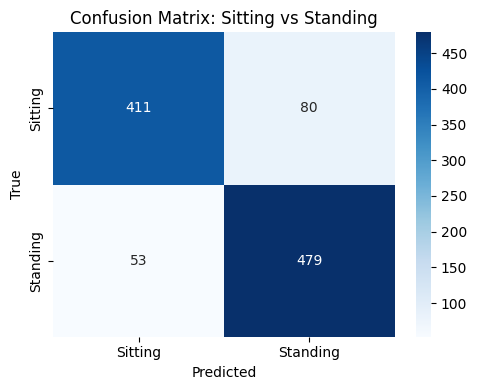

In [ ]:
# =========================
# Imports
# =========================
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Ensure tensors
# =========================
if not torch.is_tensor(X_val):
    X_val = torch.tensor(X_val, dtype=torch.float32)

if not torch.is_tensor(y_val):
    y_val = torch.tensor(y_val, dtype=torch.long)

device = next(model.parameters()).device
X_val = X_val.to(device)
y_val = y_val.to(device)

# =========================
# Prediction (FOR 2-CLASS OUTPUT)
# =========================
model.eval()
with torch.no_grad():
    logits = model(X_val)          # shape: (N, 2)
    y_pred = torch.argmax(logits, dim=1)  # shape: (N,)

y_true = y_val.view(-1)

# =========================
# Sanity check (must match)
# =========================
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

# =========================
# Metrics
# =========================
y_true_np = y_true.cpu().numpy()
y_pred_np = y_pred.cpu().numpy()

cm = confusion_matrix(y_true_np, y_pred_np)
recall = recall_score(y_true_np, y_pred_np)
f1 = f1_score(y_true_np, y_pred_np)

print("Confusion Matrix:\n", cm)
print("Recall:", recall)
print("F1-score:", f1)

# =========================
# Plot (for screenshots)
# =========================
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Sitting", "Standing"],
    yticklabels=["Sitting", "Standing"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix: Sitting vs Standing")
plt.tight_layout()
plt.show()


# CLD HAR


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── Paths (same as HAR1.ipynb) ───────────────────────────────────────────────
BASE_PATH = "/content/drive/MyDrive/UROP/UCI HAR Dataset"
SAVE_DIR  = "/content/drive/MyDrive/UROP/models"
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

LABEL_NAMES = {
    1: "WALKING",
    2: "WALKING_UPSTAIRS",
    3: "WALKING_DOWNSTAIRS",
    4: "SITTING",
    5: "STANDING",
    6: "LAYING",
}
STATIC_LABELS  = [4, 5, 6]
DYNAMIC_LABELS = [1, 2, 3]

Device: cpu


In [ ]:
SIGNALS = [
    "body_acc_x",  "body_acc_y",  "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

def load_inertial(split):
    """Returns (N, 128, 9) array of raw inertial signals."""
    data = []
    for sig in SIGNALS:
        path = os.path.join(BASE_PATH, split, "Inertial Signals", f"{sig}_{split}.txt")
        data.append(np.loadtxt(path))
    return np.stack(data, axis=-1)  # (N, 128, 9)

def load_labels(split):
    path = os.path.join(BASE_PATH, split, f"y_{split}.txt")
    return np.loadtxt(path).astype(int)

print("Loading data (this takes ~30s)...")
X_train_all = load_inertial("train")
y_train_all = load_labels("train")
X_test_all  = load_inertial("test")
y_test_all  = load_labels("test")

print(f"Train: {X_train_all.shape} | Test: {X_test_all.shape}")
print("Train label counts:", {LABEL_NAMES[k]: int((y_train_all==k).sum()) for k in range(1,7)})

Loading data (this takes ~30s)...
Train: (7352, 128, 9) | Test: (2947, 128, 9)
Train label counts: {'WALKING': 1226, 'WALKING_UPSTAIRS': 1073, 'WALKING_DOWNSTAIRS': 986, 'SITTING': 1286, 'STANDING': 1374, 'LAYING': 1407}


In [ ]:
class HARDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


class HARTransformer(nn.Module):
    def __init__(self, input_dim=9, num_classes=2):
        super().__init__()
        self.embedding = nn.Linear(input_dim, 64)
        encoder_layer  = nn.TransformerEncoderLayer(
            d_model=64, nhead=4, dim_feedforward=128, batch_first=True
        )
        self.encoder    = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.embedding(x)   # (B, 128, 64)
        x = self.encoder(x)
        x = x.mean(dim=1)       # temporal pooling
        return self.classifier(x)


def make_loader(X, y, batch_size=64, shuffle=True):
    return DataLoader(HARDataset(X, y), batch_size=batch_size, shuffle=shuffle)


def train_model(model, train_loader, val_loader, epochs=25, lr=1e-3, label=""):
    model = model.to(DEVICE)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                preds    = model(Xb).argmax(dim=1)
                total   += yb.size(0)
                correct += (preds == yb).sum().item()

        print(f"[{label}] Epoch {epoch+1:02d}/{epochs} | "
              f"Loss: {total_loss/len(train_loader):.4f} | "
              f"Val Acc: {100*correct/total:.2f}%")

    return model

print("Architecture defined.")

Architecture defined.


In [ ]:
# 1 = static, 0 = dynamic
y_tr_s1 = np.isin(y_train_all, STATIC_LABELS).astype(int)
y_te_s1 = np.isin(y_test_all,  STATIC_LABELS).astype(int)

loader_tr_s1 = make_loader(X_train_all, y_tr_s1)
loader_te_s1 = make_loader(X_test_all,  y_te_s1, shuffle=False)

print("Stage 1 train — Dynamic:", (y_tr_s1==0).sum(), "| Static:", (y_tr_s1==1).sum())

Stage 1 train — Dynamic: 3285 | Static: 4067


In [ ]:
model_s1 = HARTransformer(input_dim=9, num_classes=2)
model_s1 = train_model(model_s1, loader_tr_s1, loader_te_s1,
                        epochs=25, label="Stage1 Static/Dynamic")

torch.save(model_s1.state_dict(), f"{SAVE_DIR}/stage1_static_dynamic.pt")
print("Stage 1 saved.")

[Stage1 Static/Dynamic] Epoch 01/25 | Loss: 0.0983 | Val Acc: 99.42%
[Stage1 Static/Dynamic] Epoch 02/25 | Loss: 0.0059 | Val Acc: 99.66%
[Stage1 Static/Dynamic] Epoch 03/25 | Loss: 0.0019 | Val Acc: 99.83%
[Stage1 Static/Dynamic] Epoch 04/25 | Loss: 0.0013 | Val Acc: 99.97%
[Stage1 Static/Dynamic] Epoch 05/25 | Loss: 0.0013 | Val Acc: 99.97%
[Stage1 Static/Dynamic] Epoch 06/25 | Loss: 0.0002 | Val Acc: 100.00%
[Stage1 Static/Dynamic] Epoch 07/25 | Loss: 0.0001 | Val Acc: 99.97%
[Stage1 Static/Dynamic] Epoch 08/25 | Loss: 0.0001 | Val Acc: 100.00%
[Stage1 Static/Dynamic] Epoch 09/25 | Loss: 0.0001 | Val Acc: 100.00%
[Stage1 Static/Dynamic] Epoch 10/25 | Loss: 0.0001 | Val Acc: 100.00%
[Stage1 Static/Dynamic] Epoch 11/25 | Loss: 0.0001 | Val Acc: 100.00%
[Stage1 Static/Dynamic] Epoch 12/25 | Loss: 0.0001 | Val Acc: 100.00%
[Stage1 Static/Dynamic] Epoch 13/25 | Loss: 0.0000 | Val Acc: 100.00%
[Stage1 Static/Dynamic] Epoch 14/25 | Loss: 0.0000 | Val Acc: 100.00%
[Stage1 Static/Dynamic] Ep

In [ ]:
static_map = {4: 0, 5: 1, 6: 2}

tr_mask_2a = np.isin(y_train_all, [4, 5, 6])
te_mask_2a = np.isin(y_test_all,  [4, 5, 6])

X_tr_2a = X_train_all[tr_mask_2a]
y_tr_2a = np.vectorize(static_map.get)(y_train_all[tr_mask_2a])
X_te_2a = X_test_all[te_mask_2a]
y_te_2a = np.vectorize(static_map.get)(y_test_all[te_mask_2a])

loader_tr_2a = make_loader(X_tr_2a, y_tr_2a)
loader_te_2a = make_loader(X_te_2a, y_te_2a, shuffle=False)

print("Stage 2a train counts:")
for name, idx in [("SITTING",0),("STANDING",1),("LAYING",2)]:
    print(f"  {name}: {(y_tr_2a==idx).sum()}")

Stage 2a train counts:
  SITTING: 1286
  STANDING: 1374
  LAYING: 1407


In [ ]:
model_s2a = HARTransformer(input_dim=9, num_classes=3)
model_s2a = train_model(model_s2a, loader_tr_2a, loader_te_2a,
                         epochs=25, label="Stage2a Sit/Stand/Lay")

torch.save(model_s2a.state_dict(), f"{SAVE_DIR}/stage2a_static_3class.pt")
print("Stage 2a saved.")

[Stage2a Sit/Stand/Lay] Epoch 01/25 | Loss: 0.3516 | Val Acc: 86.03%
[Stage2a Sit/Stand/Lay] Epoch 02/25 | Loss: 0.2296 | Val Acc: 87.95%
[Stage2a Sit/Stand/Lay] Epoch 03/25 | Loss: 0.2015 | Val Acc: 85.71%
[Stage2a Sit/Stand/Lay] Epoch 04/25 | Loss: 0.2012 | Val Acc: 87.44%
[Stage2a Sit/Stand/Lay] Epoch 05/25 | Loss: 0.1908 | Val Acc: 89.62%
[Stage2a Sit/Stand/Lay] Epoch 06/25 | Loss: 0.1727 | Val Acc: 88.01%
[Stage2a Sit/Stand/Lay] Epoch 07/25 | Loss: 0.1952 | Val Acc: 89.62%
[Stage2a Sit/Stand/Lay] Epoch 08/25 | Loss: 0.1695 | Val Acc: 91.28%
[Stage2a Sit/Stand/Lay] Epoch 09/25 | Loss: 0.1547 | Val Acc: 90.58%
[Stage2a Sit/Stand/Lay] Epoch 10/25 | Loss: 0.1426 | Val Acc: 91.47%
[Stage2a Sit/Stand/Lay] Epoch 11/25 | Loss: 0.1402 | Val Acc: 91.67%
[Stage2a Sit/Stand/Lay] Epoch 12/25 | Loss: 0.1370 | Val Acc: 90.96%
[Stage2a Sit/Stand/Lay] Epoch 13/25 | Loss: 0.1284 | Val Acc: 92.24%
[Stage2a Sit/Stand/Lay] Epoch 14/25 | Loss: 0.1234 | Val Acc: 91.73%
[Stage2a Sit/Stand/Lay] Epoch 15/2

In [ ]:
dynamic_map = {1: 0, 2: 1, 3: 2}

tr_mask_2b = np.isin(y_train_all, [1, 2, 3])
te_mask_2b = np.isin(y_test_all,  [1, 2, 3])

X_tr_2b = X_train_all[tr_mask_2b]
y_tr_2b = np.vectorize(dynamic_map.get)(y_train_all[tr_mask_2b])
X_te_2b = X_test_all[te_mask_2b]
y_te_2b = np.vectorize(dynamic_map.get)(y_test_all[te_mask_2b])

loader_tr_2b = make_loader(X_tr_2b, y_tr_2b)
loader_te_2b = make_loader(X_te_2b, y_te_2b, shuffle=False)

print("Stage 2b train counts:")
for name, idx in [("WALKING",0),("WALKING_UPSTAIRS",1),("WALKING_DOWNSTAIRS",2)]:
    print(f"  {name}: {(y_tr_2b==idx).sum()}")

Stage 2b train counts:
  WALKING: 1226
  WALKING_UPSTAIRS: 1073
  WALKING_DOWNSTAIRS: 986


In [ ]:
model_s2b = HARTransformer(input_dim=9, num_classes=3)
model_s2b = train_model(model_s2b, loader_tr_2b, loader_te_2b,
                         epochs=25, label="Stage2b Walk/Up/Down")

torch.save(model_s2b.state_dict(), f"{SAVE_DIR}/stage2b_dynamic_3class.pt")
print("Stage 2b saved.")

[Stage2b Walk/Up/Down] Epoch 01/25 | Loss: 0.6885 | Val Acc: 83.20%
[Stage2b Walk/Up/Down] Epoch 02/25 | Loss: 0.1304 | Val Acc: 87.96%
[Stage2b Walk/Up/Down] Epoch 03/25 | Loss: 0.0444 | Val Acc: 92.65%
[Stage2b Walk/Up/Down] Epoch 04/25 | Loss: 0.0233 | Val Acc: 92.50%
[Stage2b Walk/Up/Down] Epoch 05/25 | Loss: 0.0104 | Val Acc: 92.86%
[Stage2b Walk/Up/Down] Epoch 06/25 | Loss: 0.0029 | Val Acc: 93.44%
[Stage2b Walk/Up/Down] Epoch 07/25 | Loss: 0.0086 | Val Acc: 91.78%
[Stage2b Walk/Up/Down] Epoch 08/25 | Loss: 0.0028 | Val Acc: 90.48%
[Stage2b Walk/Up/Down] Epoch 09/25 | Loss: 0.0018 | Val Acc: 91.93%
[Stage2b Walk/Up/Down] Epoch 10/25 | Loss: 0.0031 | Val Acc: 91.28%
[Stage2b Walk/Up/Down] Epoch 11/25 | Loss: 0.0010 | Val Acc: 90.41%
[Stage2b Walk/Up/Down] Epoch 12/25 | Loss: 0.0006 | Val Acc: 90.27%
[Stage2b Walk/Up/Down] Epoch 13/25 | Loss: 0.0004 | Val Acc: 90.48%
[Stage2b Walk/Up/Down] Epoch 14/25 | Loss: 0.0004 | Val Acc: 90.56%
[Stage2b Walk/Up/Down] Epoch 15/25 | Loss: 0.000

In [ ]:
# Reverse maps: local index → UCI label
static_reverse  = {0: 4, 1: 5, 2: 6}   # sit=4, stand=5, lay=6
dynamic_reverse = {0: 1, 1: 2, 2: 3}   # walk=1, up=2, down=3


def hierarchical_predict(X_np):
    """Full pipeline on numpy array (N, 128, 9). Returns UCI labels (1-6)."""
    X_t = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)

    # Stage 1
    model_s1.eval()
    with torch.no_grad():
        s1_preds = model_s1(X_t).argmax(dim=1).cpu().numpy()  # 0=dynamic, 1=static

    static_idx  = np.where(s1_preds == 1)[0]
    dynamic_idx = np.where(s1_preds == 0)[0]
    final_preds = np.zeros(len(X_np), dtype=int)

    # Stage 2a — static branch
    if len(static_idx) > 0:
        model_s2a.eval()
        with torch.no_grad():
            local = model_s2a(X_t[static_idx]).argmax(dim=1).cpu().numpy()
        final_preds[static_idx] = np.vectorize(static_reverse.get)(local)

    # Stage 2b — dynamic branch
    if len(dynamic_idx) > 0:
        model_s2b.eval()
        with torch.no_grad():
            local = model_s2b(X_t[dynamic_idx]).argmax(dim=1).cpu().numpy()
        final_preds[dynamic_idx] = np.vectorize(dynamic_reverse.get)(local)

    return final_preds


print("Running hierarchical inference on full test set...")
y_pred_all = hierarchical_predict(X_test_all)
print("Done.")

Running hierarchical inference on full test set...
Done.


CLASSIFICATION REPORT
                    precision    recall  f1-score   support

           WALKING       0.92      0.87      0.89       496
  WALKING_UPSTAIRS       0.98      0.87      0.92       471
WALKING_DOWNSTAIRS       0.82      0.97      0.89       420
           SITTING       0.94      0.83      0.88       491
          STANDING       0.87      0.95      0.91       532
            LAYING       0.99      1.00      1.00       537

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.91      2947
      weighted avg       0.92      0.92      0.92      2947



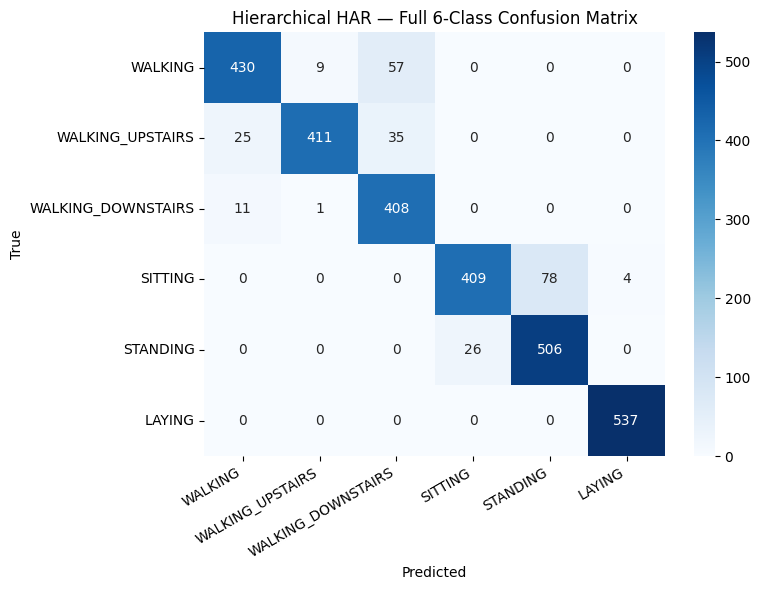

Confusion matrix saved to Drive.


In [ ]:
class_names = [LABEL_NAMES[i] for i in range(1, 7)]

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(
    y_test_all, y_pred_all,
    labels=list(range(1, 7)),
    target_names=class_names
))

cm = confusion_matrix(y_test_all, y_pred_all, labels=list(range(1, 7)))

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Hierarchical HAR — Full 6-Class Confusion Matrix")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved to Drive.")

In [ ]:
X_t_all = torch.tensor(X_test_all, dtype=torch.float32).to(DEVICE)

# Stage 1 accuracy
y_true_s1 = np.isin(y_test_all, STATIC_LABELS).astype(int)
model_s1.eval()
with torch.no_grad():
    s1_preds = model_s1(X_t_all).argmax(dim=1).cpu().numpy()
print(f"Stage 1  (Static/Dynamic)  accuracy : {(s1_preds == y_true_s1).mean()*100:.2f}%")

# Stage 2a accuracy on true static samples only
mask_static  = np.isin(y_test_all, [4, 5, 6])
s2a_acc = (y_pred_all[mask_static] == y_test_all[mask_static]).mean() * 100
print(f"Stage 2a (Sit/Stand/Lay)   accuracy : {s2a_acc:.2f}%  (true static samples only)")

# Stage 2b accuracy on true dynamic samples only
mask_dynamic = np.isin(y_test_all, [1, 2, 3])
s2b_acc = (y_pred_all[mask_dynamic] == y_test_all[mask_dynamic]).mean() * 100
print(f"Stage 2b (Walk variants)   accuracy : {s2b_acc:.2f}%  (true dynamic samples only)")

overall = (y_pred_all == y_test_all).mean() * 100
print(f"\nOverall pipeline accuracy           : {overall:.2f}%")

Stage 1  (Static/Dynamic)  accuracy : 100.00%
Stage 2a (Sit/Stand/Lay)   accuracy : 93.08%  (true static samples only)
Stage 2b (Walk variants)   accuracy : 90.05%  (true dynamic samples only)

Overall pipeline accuracy           : 91.65%


# GRAPHH


In [ ]:
# ── Extra imports ────────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc, f1_score, precision_score, recall_score
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F
import zipfile, shutil

# We need to re-run training with history tracking.
# Replace train_model with this version that returns history too.

def train_model_with_history(model, train_loader, val_loader,
                              epochs=25, lr=1e-3, label=""):
    """Same as train_model but also returns loss/acc history for plotting."""
    model = model.to(DEVICE)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                preds    = model(Xb).argmax(dim=1)
                total   += yb.size(0)
                correct += (preds == yb).sum().item()

        avg_loss = total_loss / len(train_loader)
        val_acc  = 100 * correct / total
        history["train_loss"].append(avg_loss)
        history["val_acc"].append(val_acc)

        print(f"[{label}] Epoch {epoch+1:02d}/{epochs} | "
              f"Loss: {avg_loss:.4f} | Val Acc: {val_acc:.2f}%")

    return model, history

print("Re-train all 3 stages with history tracking by running the cells below.")

Re-train all 3 stages with history tracking by running the cells below.


In [ ]:
# ── Re-train all 3 stages (captures history for curves) ─────────────────────

print("=== Stage 1: Static / Dynamic ===")
model_s1 = HARTransformer(input_dim=9, num_classes=2)
model_s1, hist_s1 = train_model_with_history(
    model_s1, loader_tr_s1, loader_te_s1, epochs=25, label="S1")

print("\n=== Stage 2a: Sit / Stand / Lay ===")
model_s2a = HARTransformer(input_dim=9, num_classes=3)
model_s2a, hist_s2a = train_model_with_history(
    model_s2a, loader_tr_2a, loader_te_2a, epochs=25, label="S2a")

print("\n=== Stage 2b: Walking Variants ===")
model_s2b = HARTransformer(input_dim=9, num_classes=3)
model_s2b, hist_s2b = train_model_with_history(
    model_s2b, loader_tr_2b, loader_te_2b, epochs=25, label="S2b")

=== Stage 1: Static / Dynamic ===
[S1] Epoch 01/25 | Loss: 0.0918 | Val Acc: 99.46%
[S1] Epoch 02/25 | Loss: 0.0036 | Val Acc: 99.52%
[S1] Epoch 03/25 | Loss: 0.0019 | Val Acc: 99.83%
[S1] Epoch 04/25 | Loss: 0.0014 | Val Acc: 99.93%
[S1] Epoch 05/25 | Loss: 0.0014 | Val Acc: 99.76%
[S1] Epoch 06/25 | Loss: 0.0039 | Val Acc: 99.63%
[S1] Epoch 07/25 | Loss: 0.0013 | Val Acc: 99.83%
[S1] Epoch 08/25 | Loss: 0.0012 | Val Acc: 99.86%
[S1] Epoch 09/25 | Loss: 0.0011 | Val Acc: 99.29%
[S1] Epoch 10/25 | Loss: 0.0039 | Val Acc: 99.86%
[S1] Epoch 11/25 | Loss: 0.0023 | Val Acc: 99.56%
[S1] Epoch 12/25 | Loss: 0.0016 | Val Acc: 99.90%
[S1] Epoch 13/25 | Loss: 0.0006 | Val Acc: 99.86%
[S1] Epoch 14/25 | Loss: 0.0002 | Val Acc: 99.93%
[S1] Epoch 15/25 | Loss: 0.0001 | Val Acc: 99.93%
[S1] Epoch 16/25 | Loss: 0.0000 | Val Acc: 99.93%
[S1] Epoch 17/25 | Loss: 0.0000 | Val Acc: 99.93%
[S1] Epoch 18/25 | Loss: 0.0000 | Val Acc: 99.93%
[S1] Epoch 19/25 | Loss: 0.0000 | Val Acc: 99.93%
[S1] Epoch 20/25

In [ ]:
# ── Flat 6-class baseline (for F1 comparison) ────────────────────────────────
# Labels remapped to 0-5 for CrossEntropyLoss
y_tr_flat = y_train_all - 1
y_te_flat = y_test_all  - 1

loader_tr_flat = make_loader(X_train_all, y_tr_flat)
loader_te_flat = make_loader(X_test_all,  y_te_flat, shuffle=False)

print("Training flat 6-class baseline...")
model_flat = HARTransformer(input_dim=9, num_classes=6)
model_flat, hist_flat = train_model_with_history(
    model_flat, loader_tr_flat, loader_te_flat, epochs=25, label="Flat")

# Get flat predictions (shift back to 1-6)
model_flat.eval()
X_t_all = torch.tensor(X_test_all, dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    y_pred_flat = model_flat(X_t_all).argmax(dim=1).cpu().numpy() + 1

print("Flat baseline done.")

Training flat 6-class baseline...
[Flat] Epoch 01/25 | Loss: 0.5736 | Val Acc: 87.58%
[Flat] Epoch 02/25 | Loss: 0.1868 | Val Acc: 88.53%
[Flat] Epoch 03/25 | Loss: 0.1454 | Val Acc: 90.53%
[Flat] Epoch 04/25 | Loss: 0.1279 | Val Acc: 87.00%
[Flat] Epoch 05/25 | Loss: 0.1277 | Val Acc: 89.51%
[Flat] Epoch 06/25 | Loss: 0.1116 | Val Acc: 91.72%
[Flat] Epoch 07/25 | Loss: 0.1057 | Val Acc: 90.30%
[Flat] Epoch 08/25 | Loss: 0.1011 | Val Acc: 90.80%
[Flat] Epoch 09/25 | Loss: 0.0940 | Val Acc: 90.43%
[Flat] Epoch 10/25 | Loss: 0.1019 | Val Acc: 89.28%
[Flat] Epoch 11/25 | Loss: 0.1031 | Val Acc: 91.55%
[Flat] Epoch 12/25 | Loss: 0.0893 | Val Acc: 91.58%
[Flat] Epoch 13/25 | Loss: 0.0861 | Val Acc: 92.20%
[Flat] Epoch 14/25 | Loss: 0.0785 | Val Acc: 91.69%
[Flat] Epoch 15/25 | Loss: 0.0768 | Val Acc: 91.58%
[Flat] Epoch 16/25 | Loss: 0.0708 | Val Acc: 91.96%
[Flat] Epoch 17/25 | Loss: 0.0623 | Val Acc: 92.77%
[Flat] Epoch 18/25 | Loss: 0.0597 | Val Acc: 92.50%
[Flat] Epoch 19/25 | Loss: 0.0

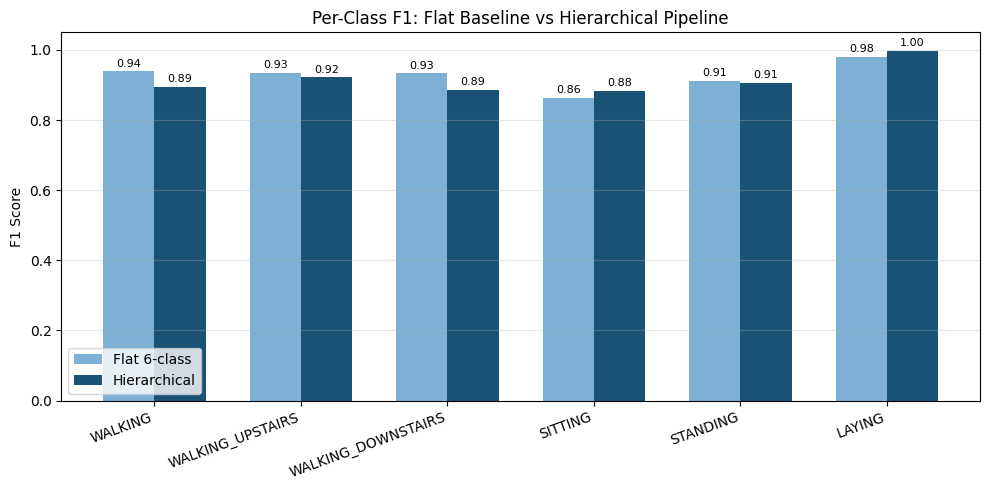

Saved.


In [ ]:
labels_16 = list(range(1, 7))
class_names = [LABEL_NAMES[i] for i in labels_16]

f1_flat = f1_score(y_test_all, y_pred_flat,  labels=labels_16, average=None)
f1_hier = f1_score(y_test_all, y_pred_all,   labels=labels_16, average=None)

x = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, f1_flat, width, label="Flat 6-class",    color="#7eb0d5")
bars2 = ax.bar(x + width/2, f1_hier, width, label="Hierarchical",     color="#1a5276")

ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1: Flat Baseline vs Hierarchical Pipeline")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=20, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
ax.bar_label(bars1, fmt='%.2f', padding=2, fontsize=8)
ax.bar_label(bars2, fmt='%.2f', padding=2, fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/f1_comparison.png", dpi=150)
plt.show()
print("Saved.")

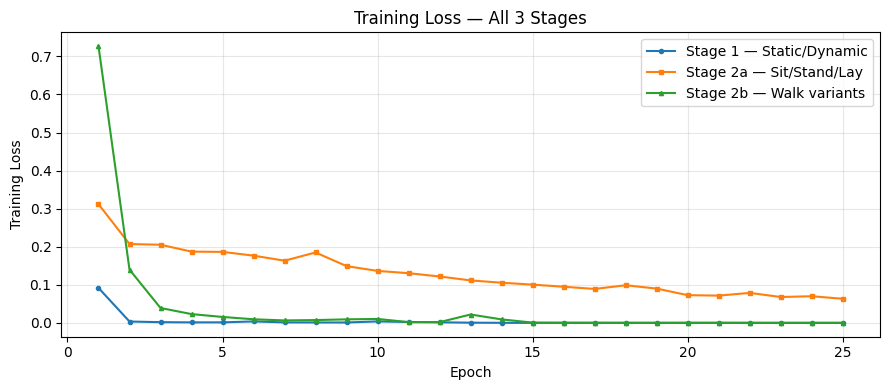

Saved.


In [ ]:
epochs_range = range(1, 26)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs_range, hist_s1["train_loss"],  label="Stage 1 — Static/Dynamic", marker='o', markersize=3)
ax.plot(epochs_range, hist_s2a["train_loss"], label="Stage 2a — Sit/Stand/Lay", marker='s', markersize=3)
ax.plot(epochs_range, hist_s2b["train_loss"], label="Stage 2b — Walk variants",  marker='^', markersize=3)

ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss")
ax.set_title("Training Loss — All 3 Stages")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/loss_curves.png", dpi=150)
plt.show()
print("Saved.")

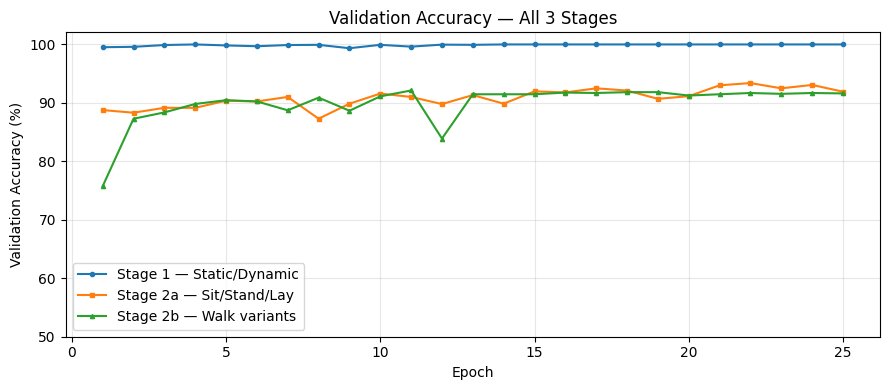

Saved.


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs_range, hist_s1["val_acc"],  label="Stage 1 — Static/Dynamic", marker='o', markersize=3)
ax.plot(epochs_range, hist_s2a["val_acc"], label="Stage 2a — Sit/Stand/Lay", marker='s', markersize=3)
ax.plot(epochs_range, hist_s2b["val_acc"], label="Stage 2b — Walk variants",  marker='^', markersize=3)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Validation Accuracy — All 3 Stages")
ax.set_ylim(50, 102)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/acc_curves.png", dpi=150)
plt.show()
print("Saved.")

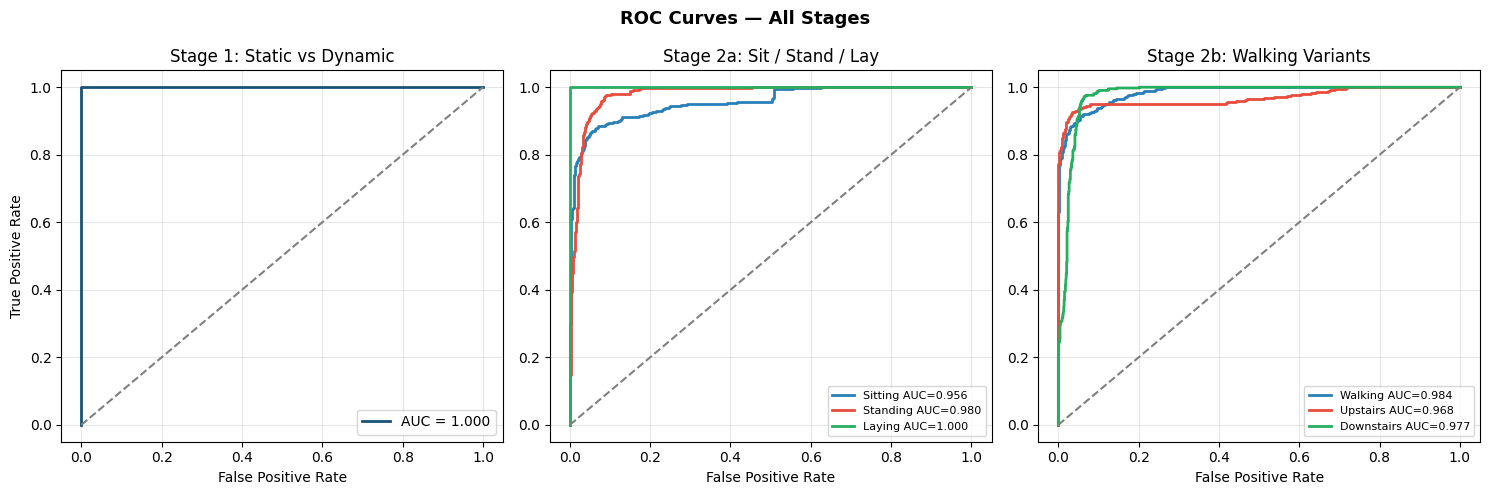

Saved.


In [ ]:
def get_probs(model, X_np):
    model.eval()
    X_t = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        probs = F.softmax(model(X_t), dim=1).cpu().numpy()
    return probs

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Stage 1 ROC (binary) ─────────────────────────────────────────────────────
probs_s1  = get_probs(model_s1, X_test_all)
y_true_s1 = np.isin(y_test_all, STATIC_LABELS).astype(int)
fpr, tpr, _ = roc_curve(y_true_s1, probs_s1[:, 1])
axes[0].plot(fpr, tpr, color='#1a5276', lw=2, label=f"AUC = {auc(fpr,tpr):.3f}")
axes[0].plot([0,1],[0,1],'--', color='grey')
axes[0].set_title("Stage 1: Static vs Dynamic")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Stage 2a ROC (3-class OvR) ───────────────────────────────────────────────
probs_s2a   = get_probs(model_s2a, X_te_2a)
y_bin_s2a   = label_binarize(y_te_2a, classes=[0,1,2])
colors_2a   = ['#2980b9','#e74c3c','#27ae60']
names_2a    = ["Sitting","Standing","Laying"]
for i, (c, n) in enumerate(zip(colors_2a, names_2a)):
    fpr, tpr, _ = roc_curve(y_bin_s2a[:, i], probs_s2a[:, i])
    axes[1].plot(fpr, tpr, color=c, lw=2, label=f"{n} AUC={auc(fpr,tpr):.3f}")
axes[1].plot([0,1],[0,1],'--', color='grey')
axes[1].set_title("Stage 2a: Sit / Stand / Lay")
axes[1].set_xlabel("False Positive Rate")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# ── Stage 2b ROC (3-class OvR) ───────────────────────────────────────────────
probs_s2b   = get_probs(model_s2b, X_te_2b)
y_bin_s2b   = label_binarize(y_te_2b, classes=[0,1,2])
colors_2b   = ['#2980b9','#e74c3c','#27ae60']
names_2b    = ["Walking","Upstairs","Downstairs"]
for i, (c, n) in enumerate(zip(colors_2b, names_2b)):
    fpr, tpr, _ = roc_curve(y_bin_s2b[:, i], probs_s2b[:, i])
    axes[2].plot(fpr, tpr, color=c, lw=2, label=f"{n} AUC={auc(fpr,tpr):.3f}")
axes[2].plot([0,1],[0,1],'--', color='grey')
axes[2].set_title("Stage 2b: Walking Variants")
axes[2].set_xlabel("False Positive Rate")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.suptitle("ROC Curves — All Stages", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/roc_curves.png", dpi=150)
plt.show()
print("Saved.")

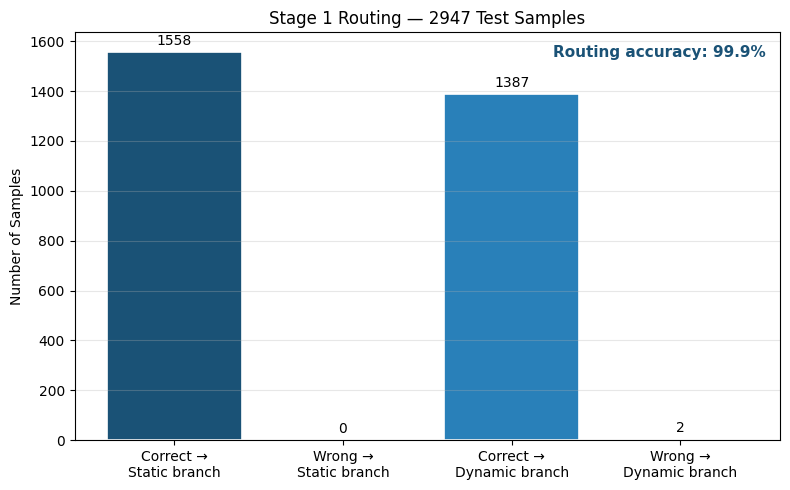

Saved.


In [ ]:
# How many samples did Stage 1 send to each branch, and how many were correct?
X_t_all   = torch.tensor(X_test_all, dtype=torch.float32).to(DEVICE)
model_s1.eval()
with torch.no_grad():
    s1_preds = model_s1(X_t_all).argmax(dim=1).cpu().numpy()

true_static  = np.isin(y_test_all, STATIC_LABELS)
true_dynamic = ~true_static

routed_static  = s1_preds == 1
routed_dynamic = s1_preds == 0

# Correct routing
correct_to_static  = (routed_static  & true_static).sum()
wrong_to_static    = (routed_static  & true_dynamic).sum()   # dynamic sent to static branch
correct_to_dynamic = (routed_dynamic & true_dynamic).sum()
wrong_to_dynamic   = (routed_dynamic & true_static).sum()    # static sent to dynamic branch

total = len(y_test_all)

fig, ax = plt.subplots(figsize=(8, 5))
categories = [
    "Correct →\nStatic branch",
    "Wrong →\nStatic branch",
    "Correct →\nDynamic branch",
    "Wrong →\nDynamic branch"
]
counts = [correct_to_static, wrong_to_static, correct_to_dynamic, wrong_to_dynamic]
colors = ['#1a5276','#e74c3c','#2980b9','#e74c3c']

bars = ax.bar(categories, counts, color=colors, edgecolor='white', linewidth=1.2)
ax.bar_label(bars, fmt='%d', padding=3)
ax.set_ylabel("Number of Samples")
ax.set_title(f"Stage 1 Routing — {total} Test Samples")
ax.grid(axis='y', alpha=0.3)

# Annotation
ax.text(0.98, 0.97,
        f"Routing accuracy: {(correct_to_static+correct_to_dynamic)/total*100:.1f}%",
        transform=ax.transAxes, ha='right', va='top',
        fontsize=11, color='#1a5276', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/routing_diagram.png", dpi=150)
plt.show()
print("Saved.")

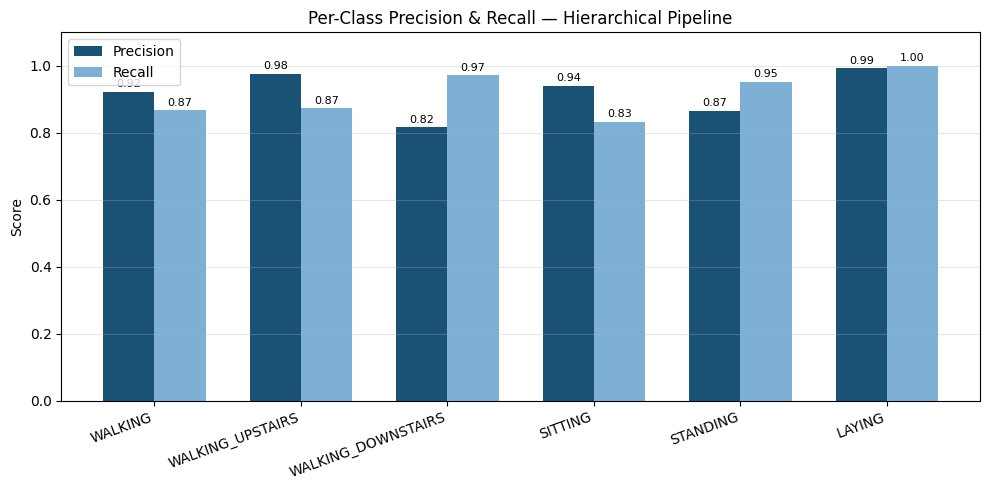

Saved.


In [ ]:
prec = precision_score(y_test_all, y_pred_all, labels=labels_16, average=None)
rec  = recall_score(   y_test_all, y_pred_all, labels=labels_16, average=None)

x     = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, prec, width, label="Precision", color="#1a5276")
b2 = ax.bar(x + width/2, rec,  width, label="Recall",    color="#7eb0d5")

ax.set_ylabel("Score")
ax.set_title("Per-Class Precision & Recall — Hierarchical Pipeline")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=20, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()
ax.bar_label(b1, fmt='%.2f', padding=2, fontsize=8)
ax.bar_label(b2, fmt='%.2f', padding=2, fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/precision_recall.png", dpi=150)
plt.show()
print("Saved.")

In [ ]:
# ── Save all 3 model weights to Drive ────────────────────────────────────────
torch.save(model_s1.state_dict(),   f"{SAVE_DIR}/stage1_static_dynamic.pt")
torch.save(model_s2a.state_dict(),  f"{SAVE_DIR}/stage2a_sit_stand_lay.pt")
torch.save(model_s2b.state_dict(),  f"{SAVE_DIR}/stage2b_walk_variants.pt")

print("All models saved to Drive:")
for f in os.listdir(SAVE_DIR):
    size = os.path.getsize(f"{SAVE_DIR}/{f}") / 1024
    print(f"  {f}  ({size:.1f} KB)")

All models saved to Drive:
  sit_stand_binary_original.pt  (275.0 KB)
  stage1_static_dynamic.pt  (274.9 KB)
  stage2a_static_3class.pt  (275.1 KB)
  stage2b_dynamic_3class.pt  (275.2 KB)
  confusion_matrix.png  (90.9 KB)
  f1_comparison.png  (71.0 KB)
  loss_curves.png  (63.6 KB)
  acc_curves.png  (66.8 KB)
  roc_curves.png  (115.5 KB)
  routing_diagram.png  (50.3 KB)
  precision_recall.png  (71.8 KB)
  stage2a_sit_stand_lay.pt  (275.1 KB)
  stage2b_walk_variants.pt  (275.1 KB)


In [ ]:
# ── Bundle models + graphs into a ZIP and download ───────────────────────────
from google.colab import files

ZIP_PATH = "/content/HAR_pipeline.zip"

with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(SAVE_DIR):
        full = os.path.join(SAVE_DIR, fname)
        zf.write(full, arcname=fname)
        print(f"  Added: {fname}")

print(f"\nZIP created at {ZIP_PATH}")
files.download(ZIP_PATH)
print("Download triggered.")

  Added: sit_stand_binary_original.pt
  Added: stage1_static_dynamic.pt
  Added: stage2a_static_3class.pt
  Added: stage2b_dynamic_3class.pt
  Added: confusion_matrix.png
  Added: f1_comparison.png
  Added: loss_curves.png
  Added: acc_curves.png
  Added: roc_curves.png
  Added: routing_diagram.png
  Added: precision_recall.png
  Added: stage2a_sit_stand_lay.pt
  Added: stage2b_walk_variants.pt

ZIP created at /content/HAR_pipeline.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered.


In [ ]:
# ── How to reload models in a future session ─────────────────────────────────
# Copy-paste this block whenever you start a new session and need the pipeline.

def load_pipeline(save_dir):
    """Loads all 3 trained models from Drive. Returns (model_s1, model_s2a, model_s2b)."""
    s1  = HARTransformer(input_dim=9, num_classes=2)
    s2a = HARTransformer(input_dim=9, num_classes=3)
    s2b = HARTransformer(input_dim=9, num_classes=3)

    s1.load_state_dict( torch.load(f"{save_dir}/stage1_static_dynamic.pt", map_location=DEVICE))
    s2a.load_state_dict(torch.load(f"{save_dir}/stage2a_sit_stand_lay.pt",  map_location=DEVICE))
    s2b.load_state_dict(torch.load(f"{save_dir}/stage2b_walk_variants.pt",  map_location=DEVICE))

    s1.to(DEVICE).eval()
    s2a.to(DEVICE).eval()
    s2b.to(DEVICE).eval()

    print("All 3 models loaded and ready.")
    return s1, s2a, s2b


# Usage:
# model_s1, model_s2a, model_s2b = load_pipeline(SAVE_DIR)
# y_pred = hierarchical_predict(X_test_all)

print("load_pipeline() defined — use it at the top of any future notebook.")

load_pipeline() defined — use it at the top of any future notebook.
